In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

data = np.load('boxplot_data.npz', allow_pickle=True)
num_annotations = data['budgets']
n_budgets = len(num_annotations)

/var/folders/sg/d0yh45390j9ct1_zwp6r1qx40000gn/T/ipykernel_47498/2932990110.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, patch_artist=True, labels=labels)


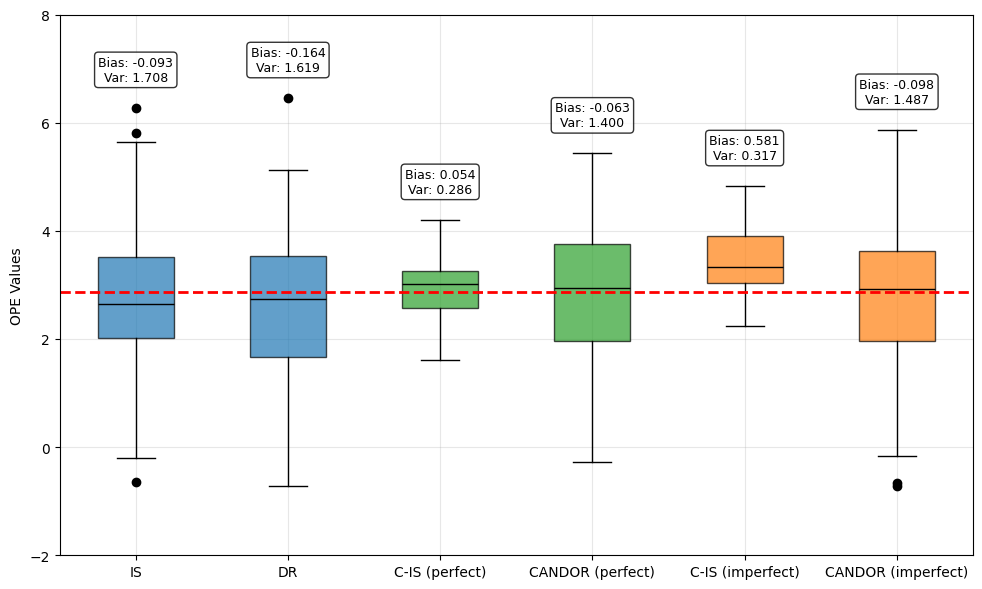

In [4]:
# Box plots for various OPE estimators
# Prepare the data for boxplot (use the largest number of annotations for C-IS and CANDOR)
box_data = [
    data['IS_estimates'],
    data['DR_estimates'],
    data['CIS_perfect_estimates'][:, -1],
    data['CANDOR_perfect_estimates'][:, -1],
    data['CIS_imperfect_estimates'][:, -1],
    data['CANDOR_imperfect_estimates'][:, -1]
]

# Labels
labels = ['IS', 'DR', 'C-IS (perfect)', 'CANDOR (perfect)', 'C-IS (imperfect)', 'CANDOR (imperfect)']

# Group colors: baseline (blue), perfect (green), imperfect (orange)
colors = ['#1f77b4', '#1f77b4', '#2ca02c', '#2ca02c', '#ff7f0e', '#ff7f0e']

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create boxplots with custom colors
bp = ax.boxplot(box_data, patch_artist=True, labels=labels)

# Color the boxes by group
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)  # Slight transparency for better visibility

# Add whiskers and caps in a neutral color
for key in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[key]:
        item.set_color('black')
        if key == 'fliers':
            item.set_markerfacecolor('black')
            item.set_markeredgecolor('black')

# Add horizontal line for true value
ax.axhline(y=data['true_value'], color='red', linestyle='--', linewidth=2, label='True Value')

# legend_elements = [
#     Patch(facecolor='#1f77b4', alpha=0.7, label='Baselines'),
#     Patch(facecolor='#2ca02c', alpha=0.7, label='Perfect Annotations'),
#     Patch(facecolor='#ff7f0e', alpha=0.7, label='Imperfect Annotations'),
#     Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Policy Value')
# ]
# ax.legend(handles=legend_elements, loc='upper left')

# Annotate bias and variance above each box
true_value = data['true_value']
for i, (label, estimates) in enumerate(zip(labels, box_data)):
    mean_est = np.mean(estimates)
    abs_bias = mean_est - true_value
    variance = np.var(estimates)
    y_pos = np.max(estimates) + (np.max([np.max(d) for d in box_data]) - np.min([np.min(d) for d in box_data])) * 0.02  # Dynamic offset based on data range
    ax.text(i + 1, y_pos + 0.3, f'Bias: {abs_bias:.3f}\nVar: {variance:.3f}',
            ha='center', va='bottom', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Customize the plot
ax.set_ylabel('OPE Values', fontsize=10)
ax.grid(True, linestyle='-', alpha=0.3)
plt.ylim([-2, 8])

plt.tight_layout()
plt.savefig('All_OPEs.png', dpi=300)
plt.show()

/var/folders/sg/d0yh45390j9ct1_zwp6r1qx40000gn/T/ipykernel_47533/121212846.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, patch_artist=True, labels=labels)


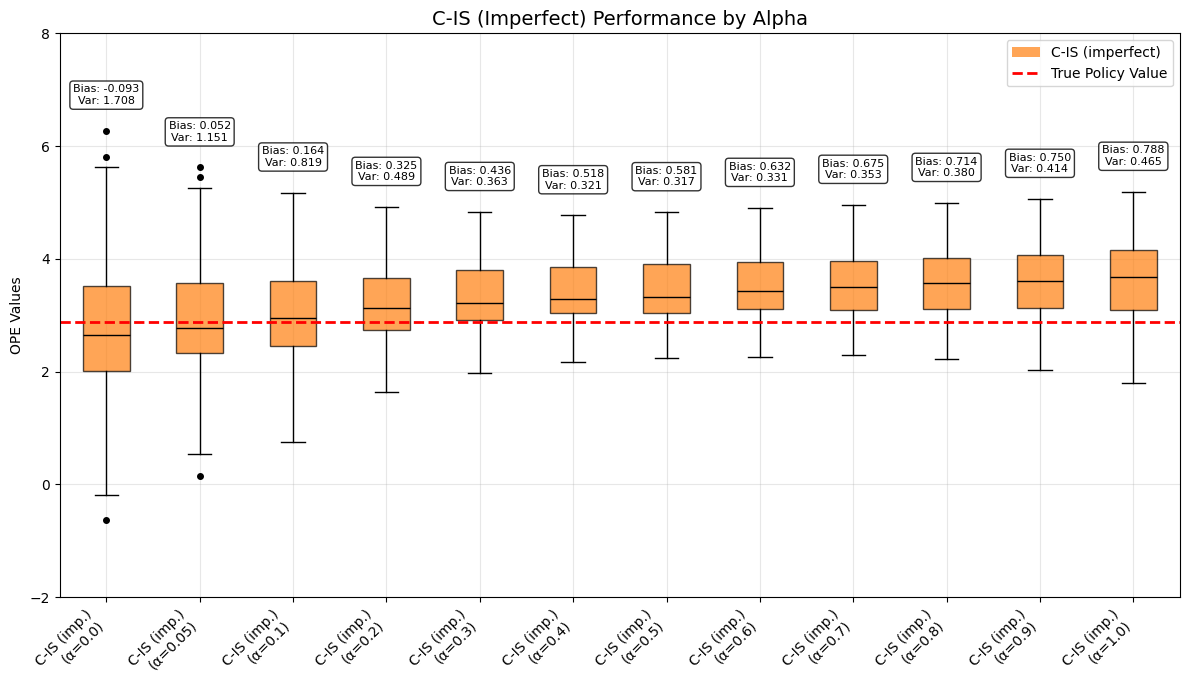

In [10]:
data = np.load('boxplot_data_alpha.npz', allow_pickle=True)
alphas = data['alphas']
n_alphas = len(alphas)
true_value = data['true_value']

cis_imperfect_data = data['CIS_imperfect_estimates']

box_data = []
labels = []

for i, alpha in enumerate(alphas):
    box_data.append(cis_imperfect_data[:, i, -1])
    labels.append(f'C-IS (imp.)\n(α={alpha})')

color = '#ff7f0e'

fig, ax = plt.subplots(figsize=(12, 7))

bp = ax.boxplot(box_data, patch_artist=True, labels=labels)

for patch in bp['boxes']:
    patch.set_facecolor(color)
    patch.set_alpha(0.7)


for key in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[key]:
        item.set_color('black')
        if key == 'fliers':
            item.set_markerfacecolor('black')
            item.set_markeredgecolor('black')
            item.set_markersize(4)

ax.axhline(y=true_value, color='red', linestyle='--', linewidth=2, label='True Value')

legend_elements = [
    Patch(facecolor='#ff7f0e', alpha=0.7, label='C-IS (imperfect)'),
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Policy Value')
]
ax.legend(handles=legend_elements, loc='upper right')


global_max = np.max([np.max(d) for d in box_data if len(d) > 0])
global_min = np.min([np.min(d) for d in box_data if len(d) > 0])
y_offset = (global_max - global_min) * 0.02

for i, estimates in enumerate(box_data):
    if len(estimates) == 0: continue

    mean_est = np.mean(estimates)
    abs_bias = mean_est - true_value
    variance = np.var(estimates)

    y_pos = np.max(estimates) + y_offset

    ax.text(i + 1, y_pos + 0.3, f'Bias: {abs_bias:.3f}\nVar: {variance:.3f}',
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title('C-IS (Imperfect) Performance by Alpha', fontsize=14)
ax.set_ylabel('OPE Values', fontsize=10)
ax.grid(True, linestyle='-', alpha=0.3)
plt.ylim([-2, 8])

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('C-IS (Imperfect) Alpha Boxplot.png', dpi=300)
plt.show()

/var/folders/sg/d0yh45390j9ct1_zwp6r1qx40000gn/T/ipykernel_47533/2430674470.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, patch_artist=True, labels=labels)


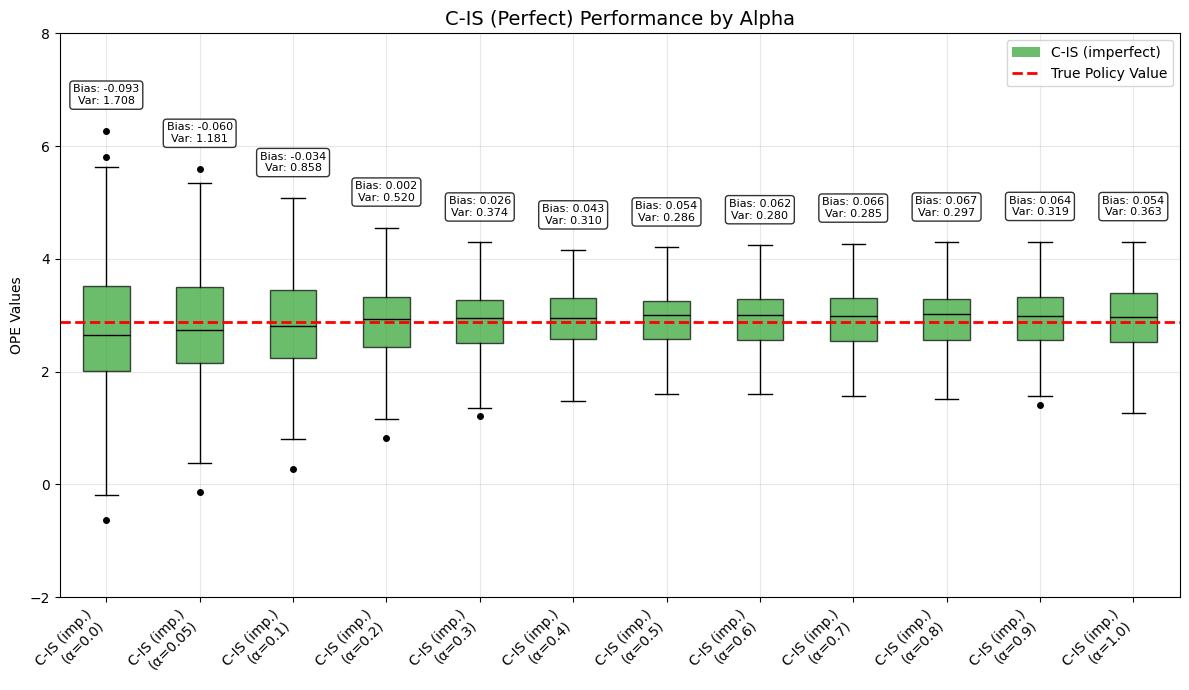

In [11]:
data = np.load('boxplot_data_alpha.npz', allow_pickle=True)
alphas = data['alphas']
n_alphas = len(alphas)
true_value = data['true_value']

cis_imperfect_data = data['CIS_perfect_estimates']

box_data = []
labels = []

for i, alpha in enumerate(alphas):
    box_data.append(cis_imperfect_data[:, i, -1])
    labels.append(f'C-IS (imp.)\n(α={alpha})')

color = '#2ca02c'

fig, ax = plt.subplots(figsize=(12, 7))

bp = ax.boxplot(box_data, patch_artist=True, labels=labels)

for patch in bp['boxes']:
    patch.set_facecolor(color)
    patch.set_alpha(0.7)


for key in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[key]:
        item.set_color('black')
        if key == 'fliers':
            item.set_markerfacecolor('black')
            item.set_markeredgecolor('black')
            item.set_markersize(4)

ax.axhline(y=true_value, color='red', linestyle='--', linewidth=2, label='True Value')

legend_elements = [
    Patch(facecolor='#2ca02c', alpha=0.7, label='C-IS (imperfect)'),
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Policy Value')
]
ax.legend(handles=legend_elements, loc='upper right')


global_max = np.max([np.max(d) for d in box_data if len(d) > 0])
global_min = np.min([np.min(d) for d in box_data if len(d) > 0])
y_offset = (global_max - global_min) * 0.02

for i, estimates in enumerate(box_data):
    if len(estimates) == 0: continue

    mean_est = np.mean(estimates)
    abs_bias = mean_est - true_value
    variance = np.var(estimates)

    y_pos = np.max(estimates) + y_offset

    ax.text(i + 1, y_pos + 0.3, f'Bias: {abs_bias:.3f}\nVar: {variance:.3f}',
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title('C-IS (Perfect) Performance by Alpha', fontsize=14)
ax.set_ylabel('OPE Values', fontsize=10)
ax.grid(True, linestyle='-', alpha=0.3)
plt.ylim([-2, 8])

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('C-IS (Perfect) Alpha Boxplot.png', dpi=300)
plt.show()

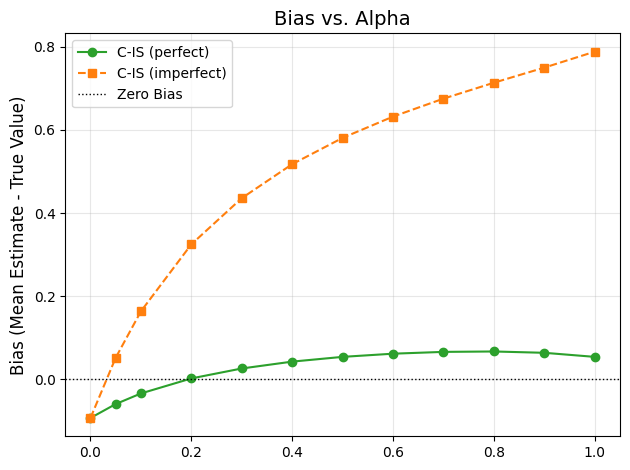

In [19]:
imperfect_data_max_budget = data['CIS_imperfect_estimates'][:, :, -1]
perfect_data_max_budget = data['CIS_perfect_estimates'][:, :, -1]

imperfect_bias = np.mean(imperfect_data_max_budget, axis=0) - true_value
perfect_bias = np.mean(perfect_data_max_budget, axis=0) - true_value

plt.plot(alphas, perfect_bias, marker='o', linestyle='-', color='#2ca02c', label='C-IS (perfect)')
plt.plot(alphas, imperfect_bias, marker='s', linestyle='--', color='#ff7f0e', label='C-IS (imperfect)')

plt.axhline(y=0, color='black', linestyle=':', linewidth=1, label='Zero Bias')

plt.title(f'Bias vs. Alpha', fontsize=14)
plt.ylabel('Bias (Mean Estimate - True Value)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='-', alpha=0.3)

plt.tight_layout()
plt.savefig('CIS_Bias_Alpha.png', dpi=300)
plt.show()

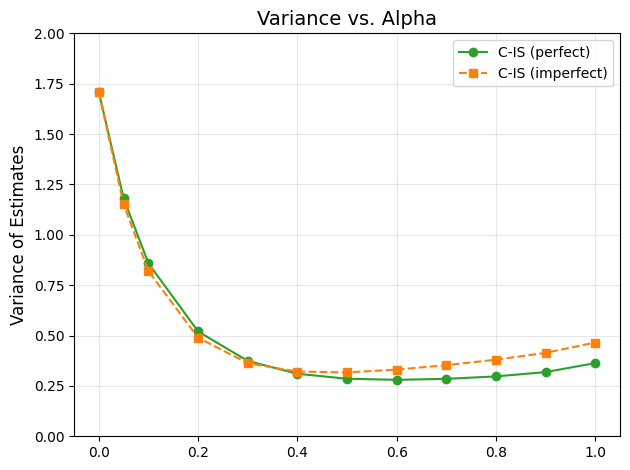

In [23]:
imperfect_data_max_budget = data['CIS_imperfect_estimates'][:, :, -1]
perfect_data_max_budget = data['CIS_perfect_estimates'][:, :, -1]

# Variance = Var(V_hat)
imperfect_var = np.var(imperfect_data_max_budget, axis=0)
perfect_var = np.var(perfect_data_max_budget, axis=0)

plt.plot(alphas, perfect_var, marker='o', linestyle='-', color='#2ca02c', label='C-IS (perfect)')
plt.plot(alphas, imperfect_var, marker='s', linestyle='--', color='#ff7f0e', label='C-IS (imperfect)')

plt.title(f'Variance vs. Alpha', fontsize=14)
plt.ylabel('Variance of Estimates', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='-', alpha=0.3)

plt.ylim([0, 2])
plt.tight_layout()
plt.savefig('CIS_Variance_Alpha.png', dpi=300)
plt.show()

/var/folders/sg/d0yh45390j9ct1_zwp6r1qx40000gn/T/ipykernel_47533/13917334.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, patch_artist=True, labels=labels)


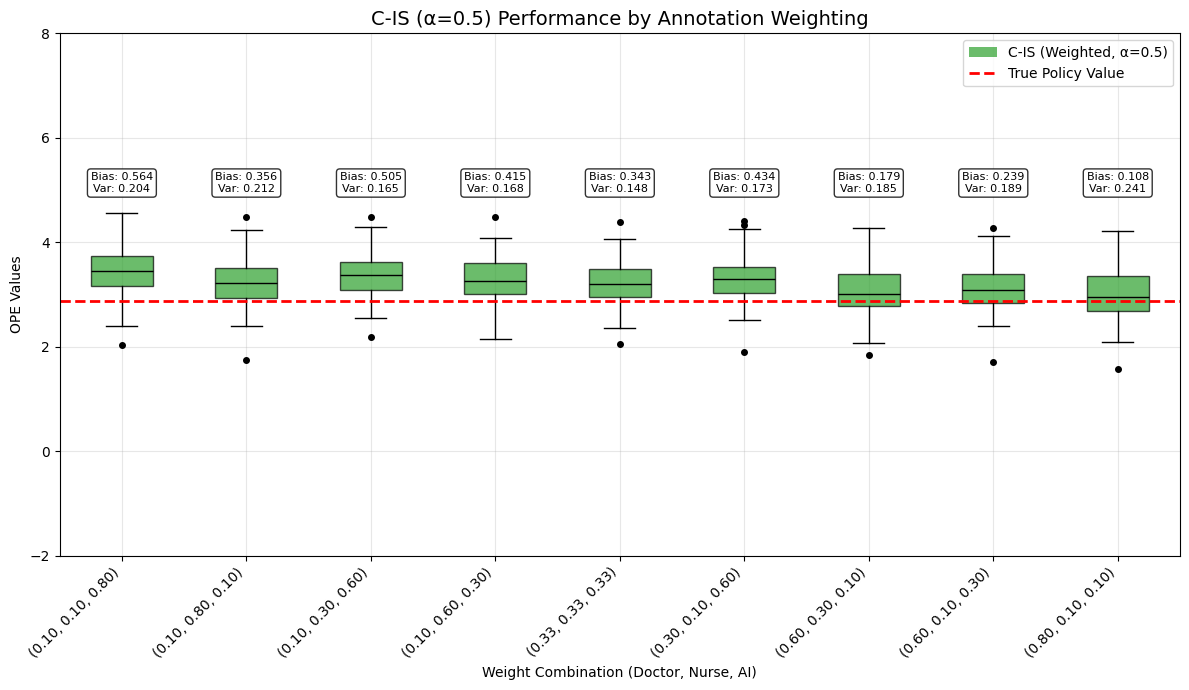

In [29]:
data = np.load('weighted_ann.npz', allow_pickle=True)

weights_data = data['weight_combinations']
budgets = data['budgets']
true_value = data['true_value']
cis_data = data['CIS_weighted_estimates']

n_weights = len(weights_data)
max_budget = budgets[-1]

box_data = []
labels = []

for i, weight_vec in enumerate(weights_data):
    data_slice = cis_data[:, i, -1]
    box_data.append(data_slice)

    label_str = f'({weight_vec[0]:.2f}, {weight_vec[1]:.2f}, {weight_vec[2]:.2f})'
    labels.append(label_str)

color = '#2ca02c'

fig, ax = plt.subplots(figsize=(12, 7))

bp = ax.boxplot(box_data, patch_artist=True, labels=labels)

for patch in bp['boxes']:
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for key in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[key]:
        item.set_color('black')
        if key == 'fliers':
            item.set_markerfacecolor('black')
            item.set_markeredgecolor('black')
            item.set_markersize(4)

ax.axhline(y=true_value, color='red', linestyle='--', linewidth=2, label='True Value')

legend_elements = [
    Patch(facecolor=color, alpha=0.7, label='C-IS (Weighted, α=0.5)'),
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Policy Value')
]
ax.legend(handles=legend_elements, loc='upper right')

global_max = np.max([np.max(d) for d in box_data if len(d) > 0])
global_min = np.min([np.min(d) for d in box_data if len(d) > 0])
y_offset = (global_max - global_min) * 0.02

text_baseline = max(global_max, true_value)

for i, estimates in enumerate(box_data):
    if len(estimates) == 0: continue

    mean_est = np.mean(estimates)
    abs_bias = mean_est - true_value
    variance = np.var(estimates)

    y_pos = text_baseline + y_offset

    ax.text(i + 1, y_pos + 0.3, f'Bias: {abs_bias:.3f}\nVar: {variance:.3f}',
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title(f'C-IS (α=0.5) Performance by Annotation Weighting', fontsize=14)
ax.set_ylabel('OPE Values', fontsize=10)
ax.set_xlabel('Weight Combination (Doctor, Nurse, AI)', fontsize=10)
ax.grid(True, linestyle='-', alpha=0.3)

plt.ylim([-2, 8])

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('CIS_Weighted_Boxplot.png', dpi=300)
plt.show()

/var/folders/sg/d0yh45390j9ct1_zwp6r1qx40000gn/T/ipykernel_47533/2011081101.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, patch_artist=True, labels=labels)


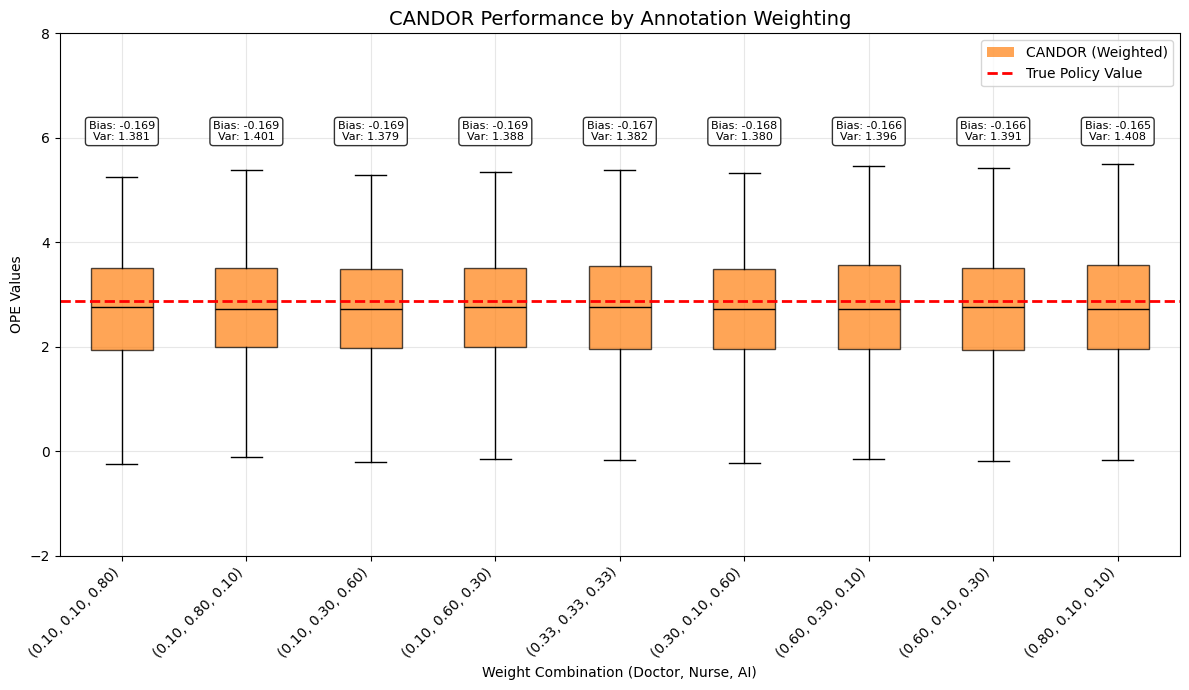

In [30]:
data = np.load('weighted_ann.npz', allow_pickle=True)

weights_data = data['weight_combinations']
budgets = data['budgets']
true_value = data['true_value']
candor_data = data['CANDOR_weighted_estimates']

n_weights = len(weights_data)
max_budget = budgets[-1]

box_data = []
labels = []

for i, weight_vec in enumerate(weights_data):
    data_slice = candor_data[:, i, -1]
    box_data.append(data_slice)

    label_str = f'({weight_vec[0]:.2f}, {weight_vec[1]:.2f}, {weight_vec[2]:.2f})'
    labels.append(label_str)

color = '#ff7f0e'

fig, ax = plt.subplots(figsize=(12, 7))

bp = ax.boxplot(box_data, patch_artist=True, labels=labels)

for patch in bp['boxes']:
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for key in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[key]:
        item.set_color('black')
        if key == 'fliers':
            item.set_markerfacecolor('black')
            item.set_markeredgecolor('black')
            item.set_markersize(4)

ax.axhline(y=true_value, color='red', linestyle='--', linewidth=2, label='True Value')

legend_elements = [
    Patch(facecolor=color, alpha=0.7, label='CANDOR (Weighted)'),
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Policy Value')
]
ax.legend(handles=legend_elements, loc='upper right')

global_max = np.max([np.max(d) for d in box_data if len(d) > 0])
global_min = np.min([np.min(d) for d in box_data if len(d) > 0])
y_offset = (global_max - global_min) * 0.02

text_baseline = max(global_max, true_value)

for i, estimates in enumerate(box_data):
    if len(estimates) == 0: continue

    mean_est = np.mean(estimates)
    abs_bias = mean_est - true_value
    variance = np.var(estimates)

    y_pos = text_baseline + y_offset

    ax.text(i + 1, y_pos + 0.3, f'Bias: {abs_bias:.3f}\nVar: {variance:.3f}',
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title(f'CANDOR Performance by Annotation Weighting', fontsize=14)
ax.set_ylabel('OPE Values', fontsize=10)
ax.set_xlabel('Weight Combination (Doctor, Nurse, AI)', fontsize=10)
ax.grid(True, linestyle='-', alpha=0.3)

plt.ylim([-2, 8])

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('CANDOR_Weighted_Boxplot.png', dpi=300)
plt.show()

In [24]:
means = [np.mean(est) for est in box_data]
variances = [np.var(est) for est in box_data]
true_value = data['true_value']

table_data = pd.DataFrame({
    'Method': labels,
    'Mean': means,
    'Variance': variances,
    'Bias': means - true_value
})


# Optionally, print the table for console output
print(table_data)

               Method      Mean  Variance      Bias
0                  IS  2.741928  2.255044 -0.133072
1                  DR  2.841116  2.157981 -0.033884
2      C-IS (perfect)  2.918901  0.296659  0.043901
3    CANDOR (perfect)  2.828986  1.894872 -0.046014
4    C-IS (imperfect)  3.479573  0.319779  0.604573
5  CANDOR (imperfect)  2.831485  1.949958 -0.043515


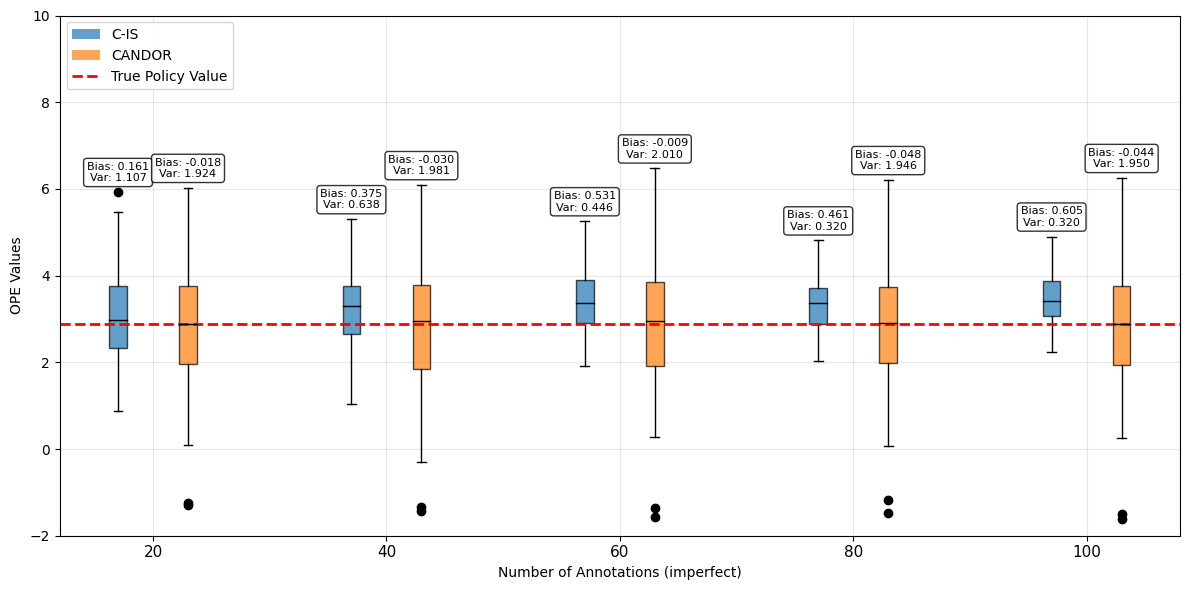

In [25]:
# Compare imperfect C-IS and CANDOR for different number of annotations
c_is_biased = [data['CIS_imperfect_estimates'][:,i] for i in range(n_budgets)]
candor_biased = [data['CANDOR_imperfect_estimates'][:,i] for i in range(n_budgets)]

# Prepare data: flatten into a list of 10 datasets (5 groups x 2 methods)
box_data = []
for i in range(n_budgets):
    box_data.append(c_is_biased[i])
    box_data.append(candor_biased[i])

# Positions for boxplots: group centers at 1,3,5,7,9; each pair offset by ±0.3
positions = []
for group in range(n_budgets):
    center = 2 * group + 1
    positions.append(center - 0.3)  # C-IS
    positions.append(center + 0.3)  # CANDOR

# Labels for x-axis (group labels at centers)
group_labels = [str(n) for n in num_annotations]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Create grouped boxplots
bp = ax.boxplot(box_data, positions=positions, widths=0.15, patch_artist=True,
                labels=[''] * len(box_data))  # No labels here

# Color the boxes: blue for C-IS, orange for CANDOR
colors = ['#1f77b4', '#ff7f0e'] * n_budgets  # Alternate per method
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Style whiskers, etc.
for key in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[key]:
        item.set_color('black')
        if key == 'fliers':
            item.set_markerfacecolor('black')
            item.set_markeredgecolor('black')

# Add x-axis labels for groups only
ax.set_xticks([2 * i + 1 for i in range(n_budgets)])  # Centers
ax.set_xticklabels(group_labels, fontsize=11)

# Add legend for methods using proxy patches
legend_elements = [
    Patch(facecolor='#1f77b4', alpha=0.7, label='C-IS'),
    Patch(facecolor='#ff7f0e', alpha=0.7, label='CANDOR'),
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Policy Value')
]
ax.legend(handles=legend_elements, loc='upper left')

# Add horizontal line for true value
ax.axhline(y=data['true_value'], color='red', linestyle='--', linewidth=2, label='True Value')

# Calculate and add bias/variance annotations
true_value = data['true_value']
y_offset = 0.2  # Vertical offset above the box
for i in range(n_budgets):
    # For C-IS (index 2*i)
    c_is_est = c_is_biased[i]
    bias_cis = np.mean(c_is_est) - true_value
    var_cis = np.var(c_is_est)
    pos_cis = positions[2*i]
    max_y_cis = np.max(c_is_est)  # Use actual max for positioning
    ax.text(pos_cis, max_y_cis + y_offset, f'Bias: {bias_cis:.3f}\nVar: {var_cis:.3f}',
            ha='center', va='bottom', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    # For CANDOR (index 2*i + 1)
    candor_est = candor_biased[i]
    bias_candor = np.mean(candor_est) - true_value
    var_candor = np.var(candor_est)
    pos_candor = positions[2*i + 1]
    max_y_candor = np.max(candor_est)
    ax.text(pos_candor, max_y_candor + y_offset, f'Bias: {bias_candor:.3f}\nVar: {var_candor:.3f}',
            ha='center', va='bottom', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Customize the plot
ax.set_ylabel('OPE Values', fontsize=10)
ax.grid(True, linestyle='-', alpha=0.3)
plt.ylim([-2, 10])
plt.xlabel('Number of Annotations (imperfect)')
# Adjust layout
plt.tight_layout()
plt.savefig("Num_Annotations_Imperfect.png", dpi=300)
plt.show()

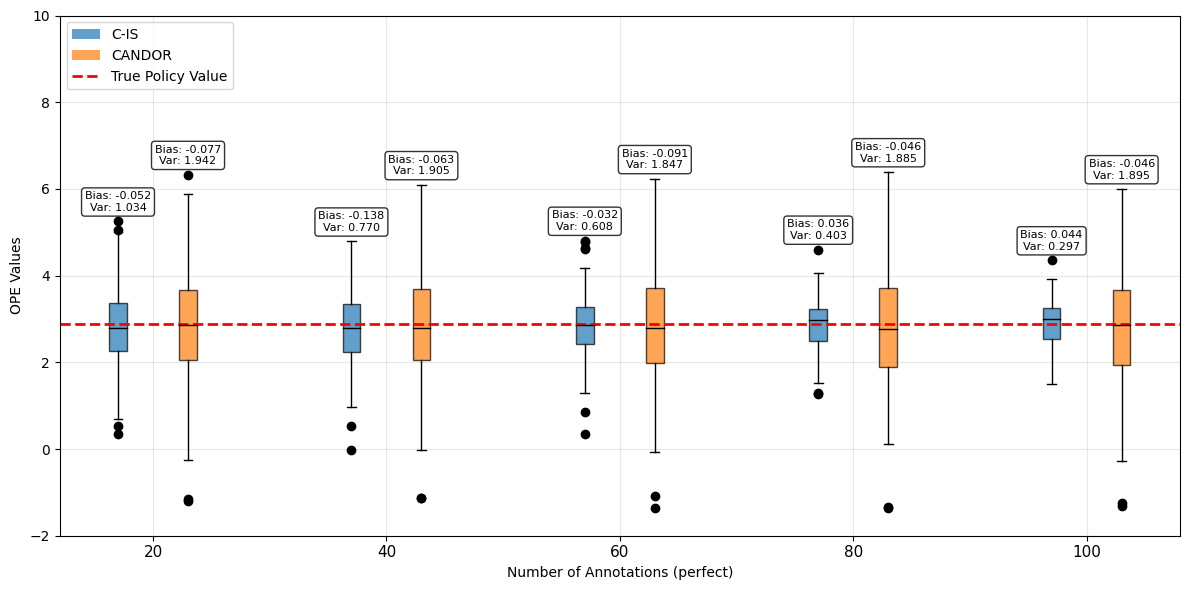

In [26]:
# Compare perfect C-IS and CANDOR for different number of annotations
c_is_perfect = [data['CIS_perfect_estimates'][:,i] for i in range(n_budgets)]
candor_perfect = [data['CANDOR_perfect_estimates'][:,i] for i in range(n_budgets)]

# Prepare data: flatten into a list of 10 datasets (5 groups x 2 methods)
box_data = []
for i in range(n_budgets):
    box_data.append(c_is_perfect[i])
    box_data.append(candor_perfect[i])

# Positions for boxplots: group centers at 1,3,5,7,9; each pair offset by ±0.3
positions = []
for group in range(n_budgets):
    center = 2 * group + 1
    positions.append(center - 0.3)  # C-IS
    positions.append(center + 0.3)  # CANDOR

# Labels for x-axis (group labels at centers)
group_labels = [str(n) for n in num_annotations]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Create grouped boxplots
bp = ax.boxplot(box_data, positions=positions, widths=0.15, patch_artist=True,
                labels=[''] * len(box_data))  # No labels here

# Color the boxes: blue for C-IS, orange for CANDOR
colors = ['#1f77b4', '#ff7f0e'] * n_budgets  # Alternate per method
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Style whiskers, etc.
for key in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[key]:
        item.set_color('black')
        if key == 'fliers':
            item.set_markerfacecolor('black')
            item.set_markeredgecolor('black')

# Add x-axis labels for groups only
ax.set_xticks([2 * i + 1 for i in range(n_budgets)])  # Centers
ax.set_xticklabels(group_labels, fontsize=11)

# Add legend for methods using proxy patches
legend_elements = [
    Patch(facecolor='#1f77b4', alpha=0.7, label='C-IS'),
    Patch(facecolor='#ff7f0e', alpha=0.7, label='CANDOR'),
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Policy Value')
]
ax.legend(handles=legend_elements, loc='upper left')

# Add horizontal line for true value
ax.axhline(y=data['true_value'], color='red', linestyle='--', linewidth=2, label='True Value')

# Calculate and add bias/variance annotations
true_value = data['true_value']
y_offset = 0.2  # Vertical offset above the box
for i in range(n_budgets):
    # For C-IS (index 2*i)
    c_is_est = c_is_perfect[i]
    bias_cis = np.mean(c_is_est) - true_value
    var_cis = np.var(c_is_est)
    pos_cis = positions[2*i]
    max_y_cis = np.max(c_is_est)  # Use actual max for positioning
    ax.text(pos_cis, max_y_cis + y_offset, f'Bias: {bias_cis:.3f}\nVar: {var_cis:.3f}',
            ha='center', va='bottom', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    # For CANDOR (index 2*i + 1)
    candor_est = candor_perfect[i]
    bias_candor = np.mean(candor_est) - true_value
    var_candor = np.var(candor_est)
    pos_candor = positions[2*i + 1]
    max_y_candor = np.max(candor_est)
    ax.text(pos_candor, max_y_candor + y_offset, f'Bias: {bias_candor:.3f}\nVar: {var_candor:.3f}',
            ha='center', va='bottom', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Customize the plot
ax.set_ylabel('OPE Values', fontsize=10)
ax.grid(True, linestyle='-', alpha=0.3)
plt.ylim([-2, 10])
plt.xlabel('Number of Annotations (perfect)')
# Adjust layout
plt.tight_layout()
plt.savefig('Num_Annotations_perfect.png', dpi=350)
plt.show()